# Componentes principais — quantos usar, e por quê

**Fase 3 da replicação · análise exploratória**

Este notebook responde uma pergunta: **quantos componentes principais (PCs) entram como covariáveis?**

O pipeline usou 5 para a coorte combinada, 9 para EUR e 10 para AFR. O plano de análise previa
*"provavelmente 4 ou 5"*. A reunião de 2026-07-01 decidiu *"não mais que 5–6"*. Os três números
discordam, e nenhum foi justificado com o dado.

Aqui o dado decide. Explicação em linguagem simples:
[`docs/07_pcs_explicados.pt.md`](../../docs/07_pcs_explicados.pt.md).

In [1]:
import sys; sys.path.insert(0, "scripts")
import pc_analysis as pc
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "600",
    "axes.titlecolor": pc.INK, "axes.labelcolor": pc.INK2, "figure.dpi": 110,
})
eig = pc.eigenvalues()
eig.head()

,cohort,PC,eigenvalue,variance_pct,drop_pct
0,combined,1,762.379,33.006135,NaN
1,combined,2,326.940,14.154411,57.115818
2,combined,3,204.934,8.872331,37.317551
3,combined,4,106.893,4.627783,47.840280
4,combined,5,81.414,3.524705,23.835986


## 1. O scree plot

Cada PC tem um **autovalor** — quanta variação genética ele captura. O primeiro captura mais, o
segundo menos, e assim por diante.

O scree plot mostra essa queda. Onde a curva **para de cair** é o "joelho": dali em diante cada PC
explica mais ou menos o mesmo que o vizinho, que é a assinatura de **ruído**, não de estrutura
populacional.

Uma série por painel, então sem legenda — o título nomeia a coorte.

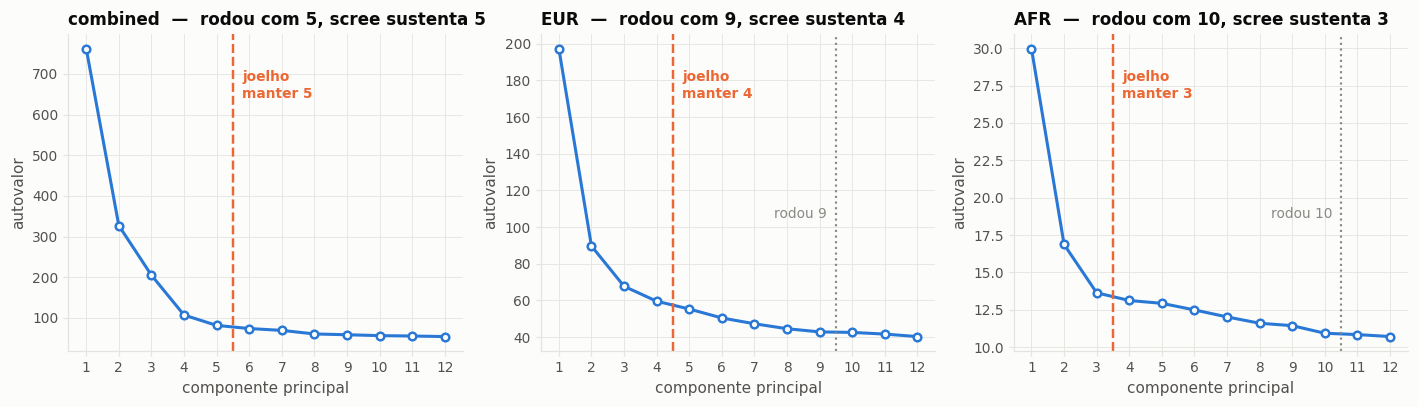

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, coh in zip(axes, ["combined", "EUR", "AFR"]):
    d = eig[eig.cohort == coh].sort_values("PC").head(12)
    k, ran = pc.elbow(eig, coh), pc.WHAT_RAN[coh]
    pc.style(ax)
    ax.plot(d.PC, d.eigenvalue, color=pc.SERIES[0], linewidth=2,
            marker="o", markersize=5, markerfacecolor="#fcfcfb", markeredgewidth=1.6)
    ax.axvline(k + 0.5, color=pc.SERIES[1], linewidth=1.6, linestyle="--")
    # rotulos em fracao do eixo, nao em coordenada de dado -- em coordenada de dado
    # o rotulo cai fora da faixa plotada quando o autovalor minimo e alto (AFR)
    ax.annotate(f"joelho\nmanter {k}", xy=(k + 0.5, 0.80), xycoords=("data", "axes fraction"),
                color=pc.SERIES[1], fontsize=9, ha="left", xytext=(6, 0),
                textcoords="offset points", fontweight="600")
    if ran != k:
        ax.axvline(ran + 0.5, color=pc.MUTED, linewidth=1.4, linestyle=":")
        ax.annotate(f"rodou {ran}", xy=(ran + 0.5, 0.42), xycoords=("data", "axes fraction"),
                    color=pc.MUTED, fontsize=9, ha="right", xytext=(-6, 0),
                    textcoords="offset points")
    ax.set_title(f"{coh}  —  rodou com {ran}, scree sustenta {k}", loc="left")
    ax.set_xlabel("componente principal"); ax.set_ylabel("autovalor")
    ax.set_xticks(range(1, 13))
fig.tight_layout(); plt.show()

## 2. A queda entre PCs consecutivos

O scree depende da escala, então é fácil discordar olhando. A queda proporcional não é: ela mede
quanto cada PC acrescenta **em relação ao anterior**.

A regra usada aqui: o joelho é o primeiro PC cuja queda fica **abaixo de 10%**. Mantemos até o
anterior a ele.

In [3]:
rows = []
for coh in ["combined", "EUR", "AFR"]:
    d = eig[eig.cohort == coh].sort_values("PC").head(8)
    for _, r in d.iterrows():
        rows.append({"coorte": coh, "PC": int(r.PC),
                     "autovalor": round(r.eigenvalue, 1),
                     "variância %": round(r.variance_pct, 2),
                     "queda vs anterior %": None if pd.isna(r.drop_pct) else round(r.drop_pct, 1),
                     "platô": "" if pd.isna(r.drop_pct) else ("sim" if r.drop_pct < 10 else "")})
tabela = pd.DataFrame(rows)
display(tabela.pivot_table(index="PC", columns="coorte",
                           values="queda vs anterior %").round(1))
print("joelho por coorte:",
      {c: pc.elbow(eig, c) for c in ["combined", "EUR", "AFR"]})

coorte,AFR,EUR,combined
PC,,,
2,43.7,54.6,57.1
3,19.2,24.5,37.3
4,3.8,12.0,47.8
5,1.4,7.1,23.8
6,3.4,8.8,9.5
7,3.8,6.3,6.1
8,3.5,5.7,12.7


joelho por coorte: {'combined': 5, 'EUR': 4, 'AFR': 3}


## 3. Variância cumulativa

Quanto da variação total os primeiros *k* PCs explicam juntos. Útil como verificação de sanidade,
mas **não** como critério: num exoma a variância total inclui muito ruído técnico, então perseguir
uma porcentagem alta leva a incluir PCs demais.

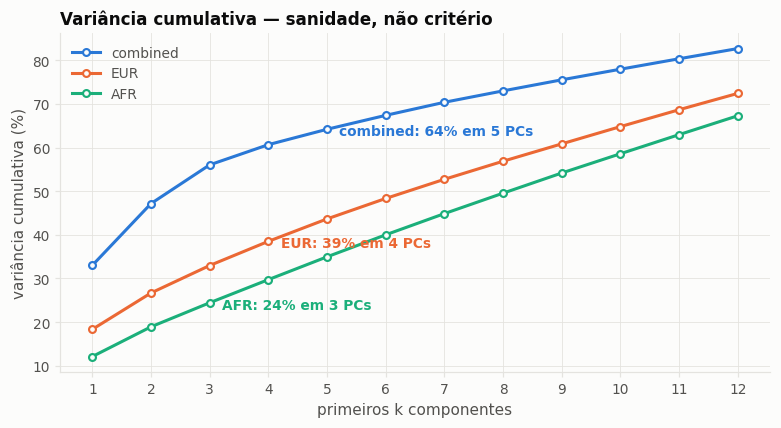

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 4))
pc.style(ax)
for i, coh in enumerate(["combined", "EUR", "AFR"]):
    d = eig[eig.cohort == coh].sort_values("PC").head(12)
    ax.plot(d.PC, d.variance_pct.cumsum(), color=pc.SERIES[i], linewidth=2,
            marker="o", markersize=4.5, markerfacecolor="#fcfcfb",
            markeredgewidth=1.4, label=coh)
    k = pc.elbow(eig, coh)
    y = d[d.PC <= k].variance_pct.sum()
    ax.annotate(f"{coh}: {y:.0f}% em {k} PCs", (k, y), color=pc.SERIES[i],
                fontsize=9, fontweight="600", xytext=(8, -4), textcoords="offset points")
ax.set_xlabel("primeiros k componentes"); ax.set_ylabel("variância cumulativa (%)")
ax.set_title("Variância cumulativa — sanidade, não critério", loc="left")
ax.set_xticks(range(1, 13)); ax.legend(frameon=False, labelcolor=pc.INK2, fontsize=9)
fig.tight_layout(); plt.show()

## 4. O gráfico que a genética usa: PC1 contra PC2

É aqui que os PCs deixam de ser abstratos. Cada ponto é uma pessoa; os eixos são os dois primeiros
componentes. Pessoas geneticamente parecidas caem perto.

O que se vê é que **os PCs recuperam ancestralidade sem nunca receber essa informação** — a PCA só
viu genótipos. Os agrupamentos emergem.

> **Nota de cor.** Scatter é forma *all-pairs*: qualquer grupo pode ficar ao lado de qualquer outro,
> e aí só três cores da paleta passam os limiares de daltonismo. Então a visão geral usa três séries
> (EUR, AFR, outros) e os grupos menores aparecem em painéis separados na seção 5.

70,925 pessoas
Class
EUR        51867
AFR        14927
EAS         1333
SAS         1080
AMR         1039
UNKNOWN      679


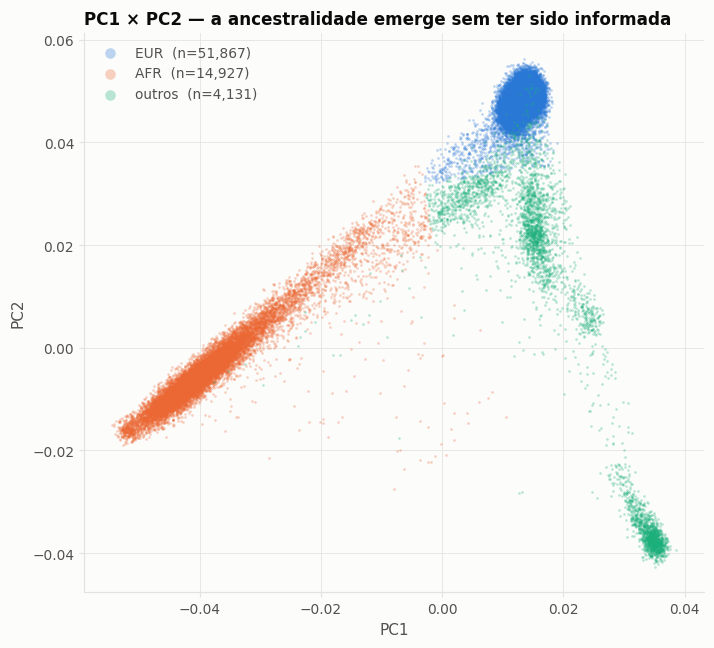

In [5]:
d = pc.pcs_with_ancestry()
print(f"{len(d):,} pessoas")
print(d.Class.value_counts().to_string())

big = ["EUR", "AFR"]
d["grupo"] = d.Class.where(d.Class.isin(big), "outros")

fig, ax = plt.subplots(figsize=(6.6, 6))
pc.style(ax)
for i, g in enumerate(["EUR", "AFR", "outros"]):
    s = d[d.grupo == g]
    ax.scatter(s.PC1, s.PC2, s=3, alpha=0.30, linewidths=0,
               color=pc.SERIES[i], label=f"{g}  (n={len(s):,})", rasterized=True)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("PC1 × PC2 — a ancestralidade emerge sem ter sido informada", loc="left")
leg = ax.legend(frameon=False, labelcolor=pc.INK2, fontsize=9, markerscale=4)
fig.tight_layout(); plt.show()

## 5. Um painel por ancestralidade

Com todos os grupos no mesmo gráfico, os menores desaparecem sob os maiores — e seis cores não
passariam o teste de daltonismo num scatter.

A solução é um painel por grupo: o grupo em destaque colorido, **todos os outros em cinza de
contexto**. Uma cor por painel, nenhum problema de contraste, e dá para ver onde cada grupo mora.

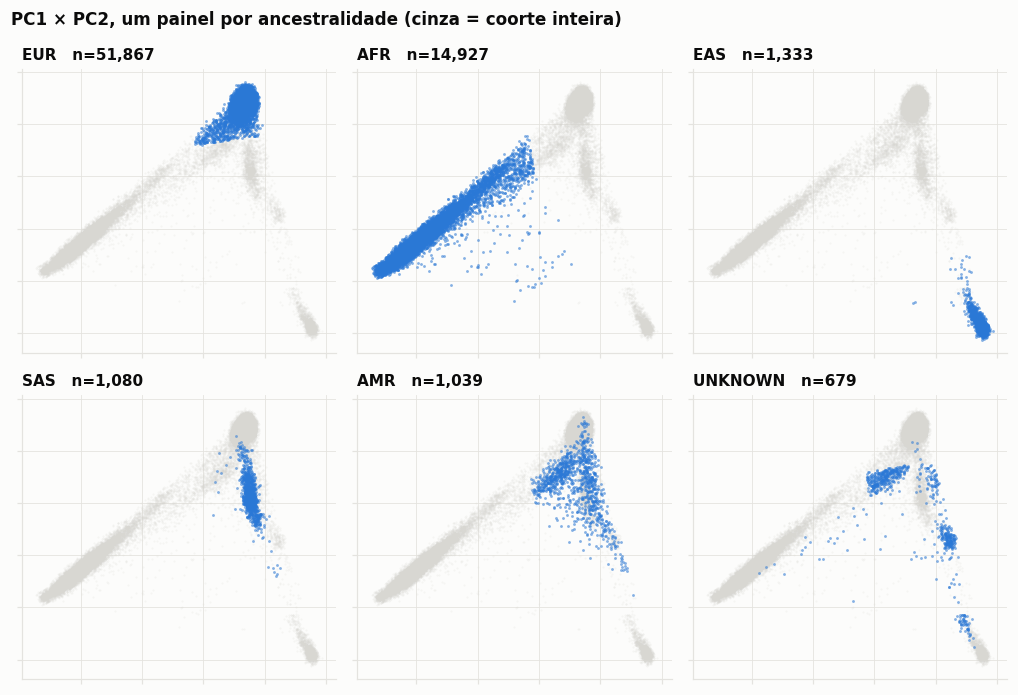

In [6]:
ordem = d.Class.value_counts().index.tolist()
n = len(ordem)
fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(3.1 * ((n + 1) // 2), 6.4))
for ax, g in zip(axes.ravel(), ordem):
    pc.style(ax)
    ax.scatter(d.PC1, d.PC2, s=2, alpha=0.18, linewidths=0,
               color=pc.CONTEXT, rasterized=True)
    s = d[d.Class == g]
    ax.scatter(s.PC1, s.PC2, s=3.5, alpha=0.55, linewidths=0,
               color=pc.SERIES[0], rasterized=True)
    ax.set_title(f"{g}   n={len(s):,}", loc="left", fontsize=10)
    ax.set_xticklabels([]); ax.set_yticklabels([])
for ax in axes.ravel()[n:]:
    ax.axis("off")
fig.suptitle("PC1 × PC2, um painel por ancestralidade (cinza = coorte inteira)",
             x=0.01, ha="left", fontsize=11, fontweight="600", color=pc.INK)
fig.tight_layout(); plt.show()

## 6. PC3 e PC4 ainda carregam estrutura?

Se sim, mantê-los faz sentido. Se os painéis já parecem uma nuvem só, o PC está capturando ruído — e
é esse o argumento para truncar.

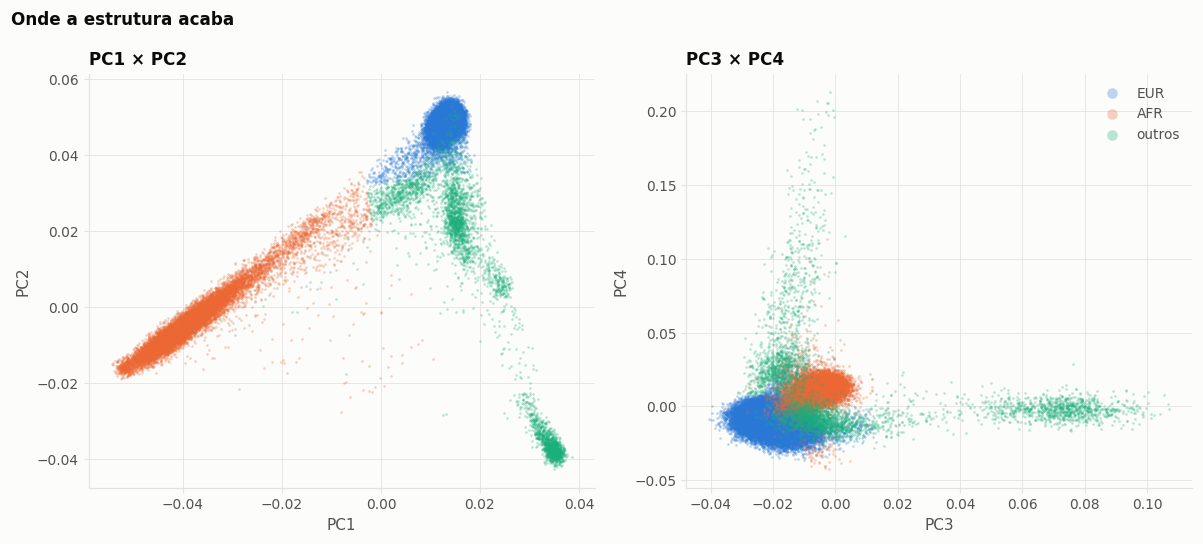

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (a, b) in zip(axes, [("PC1", "PC2"), ("PC3", "PC4")]):
    pc.style(ax)
    for i, g in enumerate(["EUR", "AFR", "outros"]):
        s = d[d.grupo == g]
        ax.scatter(s[a], s[b], s=3, alpha=0.30, linewidths=0,
                   color=pc.SERIES[i], label=g if a == "PC3" else None, rasterized=True)
    ax.set_xlabel(a); ax.set_ylabel(b)
    ax.set_title(f"{a} × {b}", loc="left")
axes[1].legend(frameon=False, labelcolor=pc.INK2, fontsize=9, markerscale=4)
fig.suptitle("Onde a estrutura acaba", x=0.01, ha="left", fontsize=11,
             fontweight="600", color=pc.INK)
fig.tight_layout(); plt.show()

## Conclusão

| coorte | rodou | scree sustenta | fonte do PC |
|---|---|---|---|
| combined | 5 | **5** ✓ | PCA do release |
| EUR | 9 | **4** | PCA própria dentro da ancestralidade |
| AFR | 10 | **3** | PCA própria dentro da ancestralidade |

**O combined estava certo.** EUR e AFR usaram mais que o dobro do que o scree sustenta.

Adotado no braço corrigido: **5 / 4 / 3**. O braço de reprodução mantém 5 / 9 / 10, porque é o que
rodou.

Um detalhe que o notebook torna visível: os PCs do `combined` vêm do release, mas os de EUR e AFR são
PCA que a Elena rodou **dentro** de cada ancestralidade — que é a prática correta. É por isso que não
existe `variance_explained` para o combined.